# 1. Your first XBeach model

**What this shows:** the smallest complete XBeach setup built with rompy-xbeach, from
a bathymetry file to a model run.

**Prerequisites:** none. This is the start of the [tutorial](../README.md).

**You will learn:**

- how rompy and rompy-xbeach split the work between *what* the model is and *when and
  where* it runs
- how a grid, bathymetry, wave forcing and physics come together in a `Config`
- how `ModelRun` writes an XBeach workspace (`params.txt` plus input files)
- how to run XBeach on that workspace with Docker

**Data used:** `bathy.tif`, a small GeoTIFF of a beach south of Perth, Western
Australia, in the [`data/`](../data) folder of this repository.

## How the pieces fit together

[rompy](https://rom-py.github.io/rompy/) provides model-agnostic building blocks such
as time periods, data sources and the `ModelRun` that generates a model workspace.
rompy-xbeach adds everything specific to XBeach. A model is described by these objects:

```text
ModelRun                 rompy: the run period, the output directory, generates files
└── config: Config       rompy-xbeach: the XBeach model
    ├── grid             where the model is (RegularGrid)
    ├── bathy            the depths on that grid (XBeachBathy)
    ├── input            forcing: wave, wind and tide data
    ├── physics          the wave model and physical processes (required)
    └── ...              boundaries, sediment, output, mpi, hotstart
```

Each object validates its own inputs, and together they write the flat `params.txt`
file XBeach reads.

## Setup

The example data ships with this repository. Outputs go to a local `_output` folder
that is safe to delete.

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from rompy.logging import config as logging_config

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "01_first_model"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. Run period

`TimeRange` comes from rompy and defines the simulation period. XBeach's `tstop` and
the time range of any forcing data are derived from it.

In [2]:
from rompy.core.time import TimeRange

period = TimeRange(start="2023-01-01T00:00", end="2023-01-01T00:30", interval="10m")
period

TimeRange(start=datetime.datetime(2023, 1, 1, 0, 0), end=datetime.datetime(2023, 1, 1, 0, 30), duration=datetime.timedelta(seconds=1800), interval=datetime.timedelta(seconds=600), include_end=True)

## 2. Model grid

A `RegularGrid` is placed by its origin, rotation `alfa` (degrees counter-clockwise
from east) and cell size and count. The cells are coarse here so the
model runs in seconds. The origin can be given in any coordinate system,
and the grid is built in the projected `crs`. [Tutorial 2](02_model_grid.ipynb)
explains the grid in detail.

<GeoAxes: >

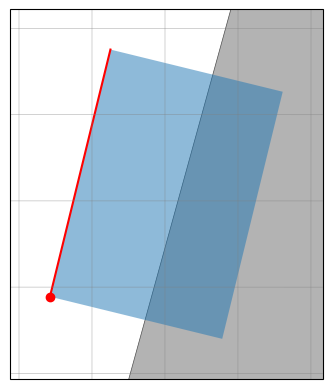

In [3]:
from rompy_xbeach.grid import RegularGrid

grid = RegularGrid(
    ori={"x": 115.594239, "y": -32.641104, "crs": "EPSG:4326"},
    alfa=347.0,
    dx=20.0,
    dy=30.0,
    nx=115,
    ny=110,
    crs="EPSG:28350",
)
grid.plot(scale="i")

The red dot is the grid origin and the red line is the offshore boundary, where wave
forcing enters the domain.

## 3. Bathymetry

`XBeachBathy` reads a data source, here a GeoTIFF, and interpolates it onto the grid.
The source uses positive-up elevations, so `posdwn=False`. The linear seaward
extension deepens the offshore edge to a uniform depth, which XBeach needs at the
wave boundary.

In [4]:
from rompy_xbeach.data.bathy import SeawardExtensionLinear, XBeachBathy
from rompy_xbeach.source import SourceGeotiff

bathy = XBeachBathy(
    source=SourceGeotiff(filename=DATA_DIR / "bathy.tif"),
    posdwn=False,
    extension=SeawardExtensionLinear(depth=15.0, slope=0.05),
)

## 4. Wave forcing

The simplest wave boundary, `BoundaryParams`, applies a constant wave height, period
and direction. `dir0`
is nautical (the direction waves come from, clockwise from north). XBeach also needs
a directional grid whenever short waves are modelled. By default its angles are
relative to the grid x-axis, so -90 to 90 degrees covers all waves travelling
towards the shore.

In [5]:
from rompy_xbeach.data.boundary import BoundaryParams

wave = BoundaryParams(
    Hrms=1.0,
    Trep=10.0,
    dir0=270.0,
    thetamin=-90.0,
    thetamax=90.0,
    dtheta=15.0,
)

## 5. Physics and boundaries

`Physics` has one required choice, the wave model. The stationary model is the fastest
and is enough for a first run. Without tide forcing, `tideloc=0` tells XBeach to keep
a constant water level `zs0`.

In [6]:
from rompy_xbeach.components.boundary.parameters import TideBoundaryConditions
from rompy_xbeach.components.physics import Physics
from rompy_xbeach.components.physics.wavemodel import Stationary

physics = Physics(wavemodel=Stationary())
tide_boundary = TideBoundaryConditions(tideloc=0, zs0=0.0)

## 6. Assemble the model

`Config` gathers all the pieces. Forcing data goes in `input`, and every other field
groups related XBeach parameters. Here the output asks for maps of wave height, water
level and bed level every 5 minutes.

In [7]:
from rompy_xbeach.components.output import Output
from rompy_xbeach.config import Config, DataInterface

config = Config(
    grid=grid,
    bathy=bathy,
    input=DataInterface(wave=wave),
    physics=physics,
    tide_boundary=tide_boundary,
    output=Output(globalvars=["H", "zs", "zb"], tintg=300.0),
)

## 7. Generate the workspace

`ModelRun` combines the config with the run period and an output directory. Calling
it writes the workspace into `output_dir/run_id`.

In [8]:
from rompy.model import ModelRun

modelrun = ModelRun(
    run_id="first_model",
    period=period,
    output_dir=OUT_DIR,
    config=config,
)
workspace = Path(modelrun())
sorted(p.name for p in workspace.iterdir())

['bathy.txt', 'params.txt', 'xdata.txt', 'ydata.txt']

The workspace holds the grid and bathymetry files (`xdata.txt`, `ydata.txt`,
`bathy.txt`) and `params.txt`, which lists every parameter set by the objects above.
Lines starting with `%` are a header with generation details, skipped here.

In [9]:
params_txt = (workspace / "params.txt").read_text()
print("\n".join(line for line in params_txt.splitlines() if not line.startswith("%")))


tstop = 1800.0
tunits = seconds since 2023-01-01 00:00:00
wbctype = params
thetamin = -90.0
thetamax = 90.0
dtheta = 15.0
Hrms = 1.0
Trep = 10.0
dir0 = 270.0
m = 10
tideloc = 0
zs0 = 0.0
posdwn = -1
vardx = 0
nx = 116
ny = 109
dx = 20.0
dy = 30.0
xori = 368106.0275474541
yori = 6387635.587309058
alfa = 347.0
projection = +proj=utm +zone=50 +south +ellps=GRS80 +units=m +no_defs +type=crs
depfile = bathy.txt
wavemodel = stationary
outputformat = netcdf
tintg = 300.0
nglobalvar = 3
H
zs
zb


## 8. Run XBeach

XBeach itself is not a Python package. The easiest way to run it is the public Docker
image `ghcr.io/rom-py/xbeach`, used here through rompy's `DockerConfig` backend. If
Docker is not installed, this step is skipped. You can also run `xbeach` from inside
the workspace folder with your own XBeach installation.

In [10]:
from rompy.backends import DockerConfig


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


if docker_available():
    backend = DockerConfig(
        image="ghcr.io/rom-py/xbeach:trunk-r6147", executable="xbeach"
    )
    ok = modelrun.run(backend, workspace_dir=workspace)
    print("XBeach finished successfully" if ok else "XBeach failed, see XBlog.txt")
else:
    print("Docker is not available, skipping the model run")

XBeach finished successfully


XBeach writes its results to `xboutput.nc`. Here is the wave height at the end of the
run, drawn on the model grid.

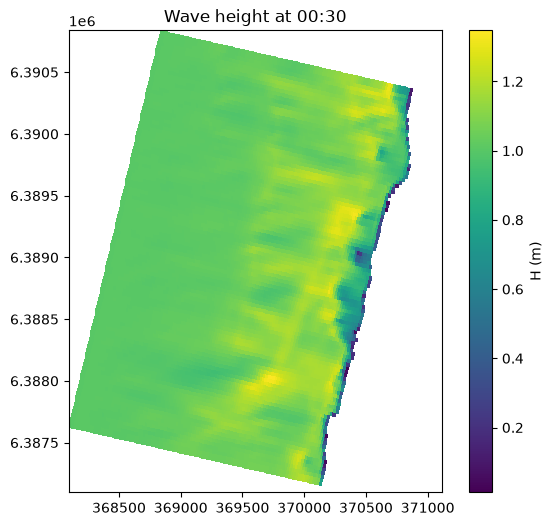

In [11]:
outfile = workspace / "xboutput.nc"
if outfile.exists():
    ds = xr.open_dataset(outfile)
    fig, ax = plt.subplots(figsize=(7, 6))
    last = ds.H.isel(globaltime=-1)
    pm = ax.pcolormesh(ds.globalx, ds.globaly, last, cmap="viridis", shading="auto")
    ax.set_aspect("equal")
    ax.set_title(f"Wave height at {last.globaltime.dt.strftime('%H:%M').item()}")
    fig.colorbar(pm, ax=ax, label="H (m)")

## Next steps

You now have the whole workflow. The next tutorials look at each part in turn:

- [2. Defining the model grid](02_model_grid.ipynb)
- [3. Bathymetry from your data](03_bathymetry.ipynb)
- [4. Adding forcing: waves, wind and water levels](04_forcing.ipynb)
- [5. Choosing model settings](05_model_settings.ipynb)
- [6. A complete storm-impact setup](06_complete_setup.ipynb)
- [7. Configuration as YAML and the rompy CLI](07_yaml_and_cli.ipynb)